In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [13]:
#test data size:
test_df = pd.read_csv(TEST_CSV)
print("Number of test mashups:", len(test_df))
test_df.head()


Number of test mashups: 3020


,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


In [5]:
import os
import random
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

STEMS_PATH = os.path.join(BASE_PATH, "genres_stems")
MASHUPS_PATH = os.path.join(BASE_PATH, "mashups")
TEST_CSV = os.path.join(BASE_PATH, "test.csv")
ESC_AUDIO = os.path.join(BASE_PATH, "ESC-50-master/audio")

GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]


In [6]:
#Class distribution (songs per genre)
genre_counts = {}

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]
    genre_counts[g] = len(songs)

df_genres = pd.DataFrame.from_dict(
    genre_counts, orient="index", columns=["num_songs"]
)

df_genres


,num_songs
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100
rock,100


In [8]:
#Stem availability / gaps
stem_files = ["drums.wav", "bass.wav", "vocals.wav", "others.wav"]
stem_stats = []

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]

    for s in songs:
        song_dir = os.path.join(genre_dir, s)
        available = sum(
            os.path.exists(os.path.join(song_dir, stem))
            for stem in stem_files
        )
        stem_stats.append({
            "genre": g,
            "song": s,
            "num_stems": available
        })

df_stems = pd.DataFrame(stem_stats)
df_stems["num_stems"].value_counts().sort_index()



num_stems
3    1000
Name: count, dtype: int64

In [9]:
#Audio length analysis — training stems
durations = []

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]

    for s in random.sample(songs, 5):  # sample few per genre
        song_dir = os.path.join(genre_dir, s)
        for stem in stem_files:
            stem_path = os.path.join(song_dir, stem)
            if os.path.exists(stem_path):
                audio, sr = librosa.load(stem_path, sr=None)
                durations.append(len(audio) / sr)

pd.Series(durations).describe()


count    150.000000
mean      30.036916
std        0.127575
min       30.000000
25%       30.000181
50%       30.013333
75%       30.013333
max       30.648889
dtype: float64

In [14]:
#Mashup duration stats
test_lengths = []

for fname in test_df["filename"].sample(20, random_state=42):
    path = os.path.join(BASE_PATH, fname)
    audio, sr = librosa.load(path, sr=None)
    test_lengths.append(len(audio) / sr)

pd.Series(test_lengths).describe()


count    20.000000
mean     26.868658
std       6.928907
min       6.282540
25%      28.954671
50%      29.872472
75%      30.013333
max      30.131519
dtype: float64

Noise file: 1-85184-A-39.wav
Duration: 5.0


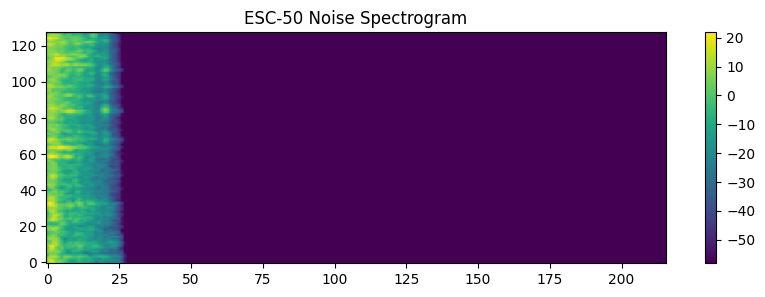

In [10]:
#esc 50
noise_file = random.choice(os.listdir(ESC_AUDIO))
noise_path = os.path.join(ESC_AUDIO, noise_file)

noise, sr = librosa.load(noise_path, sr=22050)
print("Noise file:", noise_file)
print("Duration:", len(noise)/sr)

noise_spec = librosa.feature.melspectrogram(y=noise, sr=sr)
noise_log = librosa.power_to_db(noise_spec)

plt.figure(figsize=(10, 3))
plt.imshow(noise_log, aspect="auto", origin="lower")
plt.title("ESC-50 Noise Spectrogram")
plt.colorbar()
plt.show()


In [14]:
import os
import random
import librosa
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# ================= PATHS ================= #

import os
import pandas as pd

BASE_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_DIR = os.path.join(BASE_DIR, "genres_stems")
TEST_DIR  = os.path.join(BASE_DIR, "mashups")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

OUT_PATH = "/kaggle/working/submission.csv"


# ================= CONFIG ================= #

SR = 22050
DURATION = 5
SAMPLES = SR * DURATION
MIN_STEMS_REQUIRED = 2

GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]

random.seed(42)
np.random.seed(42)

# ================= AUDIO UTILS ================= #

def load_audio(path):
    audio, _ = librosa.load(path, sr=SR, mono=True)
    if len(audio) < SAMPLES:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))
    return audio[:SAMPLES]

def extract_mfcc(audio):
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=20)
    return np.mean(mfcc, axis=1)

# ================= BUILD TRAIN DATA ================= #

X_train, y_train = [], []

print("Building training data...")

for genre in GENRES:
    genre_path = os.path.join(STEMS_DIR, genre)

    song_dirs = [
        d for d in os.listdir(genre_path)
        if os.path.isdir(os.path.join(genre_path, d))
    ]

    for _ in range(100):
        chosen = random.sample(song_dirs, 4)
        mix = np.zeros(SAMPLES)
        used = 0

        for stem_name, song in zip(
            ["drums.wav", "bass.wav", "vocals.wav", "others.wav"],
            chosen
        ):
            stem_path = os.path.join(genre_path, song, stem_name)
            if not os.path.exists(stem_path):
                continue

            audio = load_audio(stem_path)
            mix += audio
            used += 1

        if used < MIN_STEMS_REQUIRED:
            continue

        mix = mix / (np.max(np.abs(mix)) + 1e-6)

        X_train.append(extract_mfcc(mix))
        y_train.append(genre)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("Training samples:", X_train.shape[0])
print("Genres present:", set(y_train))

# ================= MODEL ================= #

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

# ================= VALIDATION ================= #

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nTraining on train split...")
model.fit(X_tr, y_tr)

print("Evaluating on validation split...")
y_val_pred = model.predict(X_val)

macro_f1 = f1_score(y_val, y_val_pred, average="macro")
print("\nValidation Macro F1:", macro_f1)

print("\nPer-class report:")
print(classification_report(y_val, y_val_pred))

# ================= TRAIN ON FULL DATA ================= #

print("Retraining on full training data...")
model.fit(X_train, y_train)

# ================= TEST INFERENCE ================= #

print("Running inference on test mashups...")
test_df = pd.read_csv(TEST_CSV)

predictions = []

for fname in test_df["filename"]:
    audio_path = os.path.join(BASE_DIR, fname)
    audio = load_audio(audio_path)
    feats = extract_mfcc(audio).reshape(1, -1)
    predictions.append(model.predict(feats)[0])

# ================= SUBMISSION ================= #

submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": predictions
})

submission.to_csv("submission.csv", index=False)
print("\nSaved submission:")


Building training data...
Training samples: 1000
Genres present: {np.str_('country'), np.str_('disco'), np.str_('classical'), np.str_('reggae'), np.str_('rock'), np.str_('pop'), np.str_('metal'), np.str_('blues'), np.str_('jazz'), np.str_('hiphop')}

Training on train split...
Evaluating on validation split...

Validation Macro F1: 0.49818559102051685

Per-class report:
              precision    recall  f1-score   support

       blues       0.48      0.50      0.49        20
   classical       0.68      0.85      0.76        20
     country       0.38      0.25      0.30        20
       disco       0.44      0.35      0.39        20
      hiphop       0.47      0.45      0.46        20
        jazz       0.53      0.45      0.49        20
       metal       0.58      0.95      0.72        20
         pop       0.78      0.90      0.84        20
      reggae       0.27      0.20      0.23        20
        rock       0.33      0.30      0.32        20

    accuracy                   

In [19]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [20]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [23]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]

STEMS =  os.path.join(BASE_PATH, "genres_stems")
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
import os
import random
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MASHUPS_PATH = os.path.join(BASE_PATH, "mashups")
TEST_CSV = os.path.join(BASE_PATH, "test.csv")
ESC_AUDIO = os.path.join(BASE_PATH, "ESC-50-master/audio")



In [25]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}

    rng = random.Random(seed)

    corrupted_count = 0
    small_file_count = 0

    for genre in GENRES:
        genre_path = os.path.join(root_dir, genre)
        if not os.path.isdir(genre_path):
            continue

        songs = [
            d for d in os.listdir(genre_path)
            if os.path.isdir(os.path.join(genre_path, d))
        ]

        rng.shuffle(songs)
        split_idx = int(len(songs) * (1 - val_split))
        train_songs = songs[:split_idx]
        val_songs = songs[split_idx:]

        for split, song_list in zip(
            ["train", "val"], [train_songs, val_songs]
        ):
            for song in song_list:
                song_path = os.path.join(genre_path, song)

                for stem_file, stem_key in STEMS.items():
                    stem_path = os.path.join(song_path, stem_file)
                    if not os.path.exists(stem_path):
                        continue

                    size_bytes = os.path.getsize(stem_path)

                    # corrupted sounds (< 4 KB)
                    if size_bytes < 4 * 1024:
                        corrupted_count += 1

                    # sounds smaller than 5.0491 MB
                    if size_bytes < 5.0491 * 1024 * 1024:
                        small_file_count += 1

                    if split == "train":
                        train_dataset[genre][stem_key].append(stem_path)
                    else:
                        val_dataset[genre][stem_key].append(stem_path)

    print("CORRUPTED (<4KB):", corrupted_count)
    print("SMALL (<5.0491MB):", small_file_count)
    print("Q1 ANSWER:", corrupted_count + small_file_count)
    def add_to_dict(target_dict, song_list):
            pass
    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)

CORRUPTED (<4KB): 0
SMALL (<5.0491MB): 0
Q1 ANSWER: 0


In [27]:
import pandas as pd
STEMS = {
    "drums.wav": "drums",
    "vocals.wav": "vocals",
    "bass.wav": "bass",
    "others.wav": "other"
}

ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

data = build_dataset(ROOT)
df = pd.DataFrame(data)

# files smaller than 5.0491 MB
small_files = df[df["size_bytes"] < 5.0491 * 1024 * 1024]

# files larger than 5.0493 MB
large_files = df[df["size_bytes"] > 5.0493 * 1024 * 1024]

answer_q2 = abs(len(large_files) - len(small_files))

print("FILES < 5.0491MB:", len(small_files))
print("FILES > 5.0493MB:", len(large_files))
print("Q2 ANSWER:", answer_q2)


CORRUPTED (<4KB): 0
SMALL (<5.0491MB): 942
Q1 ANSWER: 942


KeyError: 'size_bytes'

In [4]:
import os

def build_dataset(root_dir):
    sizes = []

    for genre in os.listdir(root_dir):
        genre_path = os.path.join(root_dir, genre)
        if not os.path.isdir(genre_path):
            continue

        for song in os.listdir(genre_path):
            song_path = os.path.join(genre_path, song)
            if not os.path.isdir(song_path):
                continue

            for file in os.listdir(song_path):
                if file.endswith(".wav"):
                    sizes.append(os.path.getsize(os.path.join(song_path, file)))

    return sizes


ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
sizes = build_dataset(ROOT)

small = [s for s in sizes if s < 5.0491 * 1024 * 1024]

print("Total training sounds:", len(sizes))
print("Sounds < 5.0491MB:", len(small))
print("Q1 ANSWER:", len(small))


Total training sounds: 4000
Sounds < 5.0491MB: 1256
Q1 ANSWER: 1256


In [5]:
ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

sizes = build_dataset(ROOT)

small = [s for s in sizes if s < 5.0491 * 1024 * 1024]
large = [s for s in sizes if s > 5.0493 * 1024 * 1024]

q2_answer = abs(len(large) - len(small))

print("Sounds < 5.0491MB:", len(small))
print("Sounds > 5.0493MB:", len(large))
print("Q2 ANSWER:", q2_answer)


Sounds < 5.0491MB: 1256
Sounds > 5.0493MB: 184
Q2 ANSWER: 1072


In [7]:
import os
import random

def build_dataset(root_dir, val_split=0.17, seed=42):
    rng = random.Random(seed)

    train_counts = {
        "reggae": {"drums": 0},
        "country": {"vocals": 0}
    }

    val_counts = {
        "reggae": {"drums": 0},
        "country": {"vocals": 0}
    }

    for genre in os.listdir(root_dir):
        genre_path = os.path.join(root_dir, genre)
        if not os.path.isdir(genre_path):
            continue

        songs = [
            s for s in os.listdir(genre_path)
            if os.path.isdir(os.path.join(genre_path, s))
        ]

        rng.shuffle(songs)
        split_idx = int(len(songs) * (1 - val_split))
        train_songs = songs[:split_idx]
        val_songs = songs[split_idx:]

        for song in train_songs:
            song_path = os.path.join(genre_path, song)
            if genre == "reggae":
                if os.path.exists(os.path.join(song_path, "drums.wav")):
                    train_counts["reggae"]["drums"] += 1

        for song in val_songs:
            song_path = os.path.join(genre_path, song)
            if genre == "country":
                if os.path.exists(os.path.join(song_path, "vocals.wav")):
                    val_counts["country"]["vocals"] += 1

    return train_counts, val_counts
ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

train_counts, val_counts = build_dataset(ROOT)

train_reggae_drums = train_counts["reggae"]["drums"]
val_country_vocals = val_counts["country"]["vocals"]

q3_answer = abs(train_reggae_drums - val_country_vocals)

print("Training reggae drums:", train_reggae_drums)
print("Validation country vocals:", val_country_vocals)
print("Q3 ANSWER:", q3_answer)


Training reggae drums: 83
Validation country vocals: 17
Q3 ANSWER: 66


In [5]:
import librosa
import numpy as np

def find_long_silences(audio_path, sr=22050, frame_len=2048, hop_len=512, energy_thresh=0.01):
    y, sr = librosa.load(audio_path, sr=sr)

    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_len,
        hop_length=hop_len
    )[0]

    silent = rms < energy_thresh

    segments = []
    count = 0

    for s in silent:
        if s:
            count += 1
        else:
            if count > 0:
                segments.append(count)
                count = 0

    if count > 0:
        segments.append(count)

    return [(seg * hop_len) / sr for seg in segments]


In [ ]:
import os

ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

count_files = 0

for genre in os.listdir(ROOT):
    genre_path = os.path.join(ROOT, genre)
    if not os.path.isdir(genre_path):
        continue

    for song in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song)
        if not os.path.isdir(song_path):
            continue

        for file in os.listdir(song_path):
            if not file.endswith(".wav"):
                continue

            audio_path = os.path.join(song_path, file)
            silences = find_long_silences(audio_path)

            if any(s >= 5 for s in silences):
                count_files += 1

print("Q4 ANSWER:", count_files)


In [7]:
import os

ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

vocal_count = 0

for genre in os.listdir(ROOT):
    genre_path = os.path.join(ROOT, genre)
    if not os.path.isdir(genre_path):
        continue

    for song in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song)
        if not os.path.isdir(song_path):
            continue

        vocal_path = os.path.join(song_path, "vocals.wav")
        if not os.path.exists(vocal_path):
            continue

        silences = find_long_silences(vocal_path)

        if any(s >= 5 for s in silences):
            vocal_count += 1

print("Q5 ANSWER:", vocal_count)


Q5 ANSWER: 382
